# Classical ML Pipeline — Evaluation (SVM / KNN / Logistic Regression)

Mirrors the structure of `pipeline_eval.ipynb` and `xgb_eval.ipynb` for direct comparison.

Primary metric: **Recall**. Secondary: Precision, F1, ROC-AUC, confusion matrix.  
Final cell produces a 5-model comparison table: CNN · XGBoost · SVM · KNN · LR.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import datetime
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

STRUCTURES = ['Decks', 'Pavements', 'Walls']
MODEL_KEYS = ['svm', 'knn', 'lr']
MODEL_LABELS = {'svm': 'SVM', 'knn': 'KNN', 'lr': 'Logistic Regression'}
COLORS = {'svm': 'steelblue', 'knn': 'darkorange', 'lr': 'seagreen'}

## Load Models, Thresholds & Splits

In [2]:
structure_models = {}
defect_models    = {}
for key in MODEL_KEYS:
    with open(f'models/classical/{key}_structure_model.pkl', 'rb') as f:
        structure_models[key] = pickle.load(f)
    defect_models[key] = {}
    for struct in STRUCTURES:
        with open(f'models/classical/{key}_defect_{struct.lower()}.pkl', 'rb') as f:
            defect_models[key][struct] = pickle.load(f)

with open('models/classical/classical_thresholds.json') as f:
    thresholds = json.load(f)

df_test = pd.read_csv('splits/test_split.csv')
df_val  = pd.read_csv('splits/val_split.csv')
X_test  = np.load('features/features_test.npy')
X_val   = np.load('features/features_val.npy')

print('Thresholds:')
for key in MODEL_KEYS:
    print(f'  {MODEL_LABELS[key]}: {thresholds[key]}')
print(f'\nTest set: {len(df_test):,} images')
print(df_test.groupby(['structure', 'label']).size().unstack(fill_value=0))

Thresholds:
  SVM: {'Decks': 0.2, 'Pavements': 0.2, 'Walls': 0.2}
  KNN: {'Decks': 0.2, 'Pavements': 0.3, 'Walls': 0.2}
  Logistic Regression: {'Decks': 0.5, 'Pavements': 0.5, 'Walls': 0.5}

Test set: 8,740 images
label      defect  no_defect
structure                   
Decks         317       1951
Pavements     381       3319
Walls         641       2131


## Stage 1 Evaluation — Structure Classifiers

SVM: acc=0.907  per-class recall=[0.813, 0.945, 0.933]


KNN: acc=0.823  per-class recall=[0.778, 0.961, 0.674]
Logistic Regression: acc=0.907  per-class recall=[0.835, 0.954, 0.902]


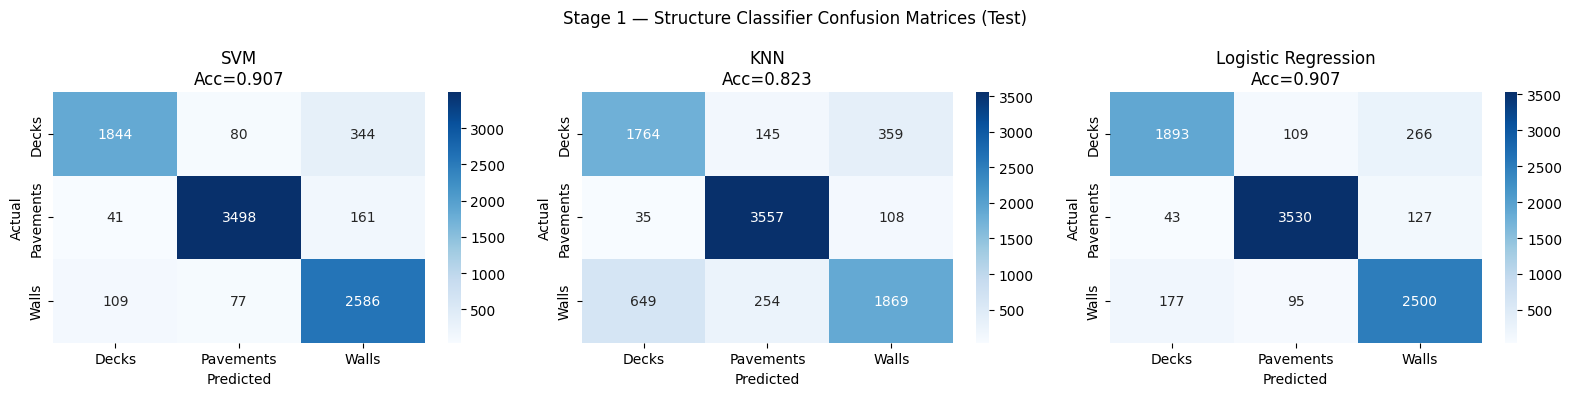

In [3]:
s1_true = df_test['structure_idx'].values
s1_accs = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key in zip(axes, MODEL_KEYS):
    preds = structure_models[key].predict(X_test)
    acc   = (preds == s1_true).mean()
    s1_accs[key] = acc
    cm = confusion_matrix(s1_true, preds)
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    print(f'{MODEL_LABELS[key]}: acc={acc:.3f}  '
          f'per-class recall={[round(r,3) for r in per_class_recall]}')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STRUCTURES, yticklabels=STRUCTURES)
    ax.set_title(f'{MODEL_LABELS[key]}\nAcc={acc:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig.suptitle('Stage 1 — Structure Classifier Confusion Matrices (Test)', fontsize=12)
plt.tight_layout()
plt.show()

## Stage 2 Evaluation — Per-Structure Defect Models (Oracle Routing)


--- SVM ---
  Decks: recall=0.107  prec=0.872  F1=0.191  AUC=0.684  (t=0.2)  FN=283
  Pavements: recall=0.134  prec=0.381  F1=0.198  AUC=0.668  (t=0.2)  FN=330


  Walls: recall=0.911  prec=0.245  F1=0.386  AUC=0.646  (t=0.2)  FN=57


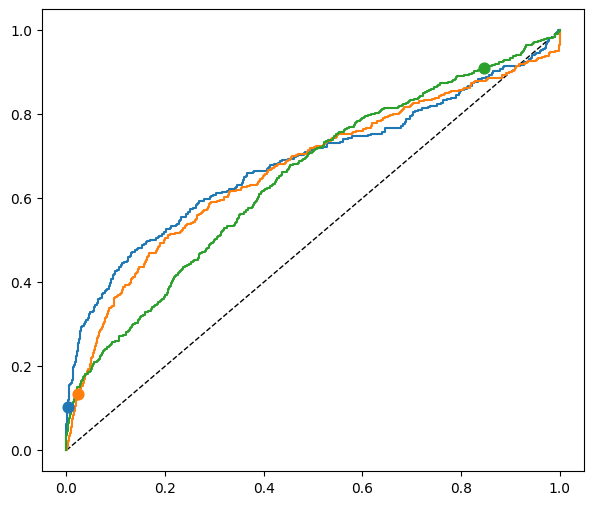

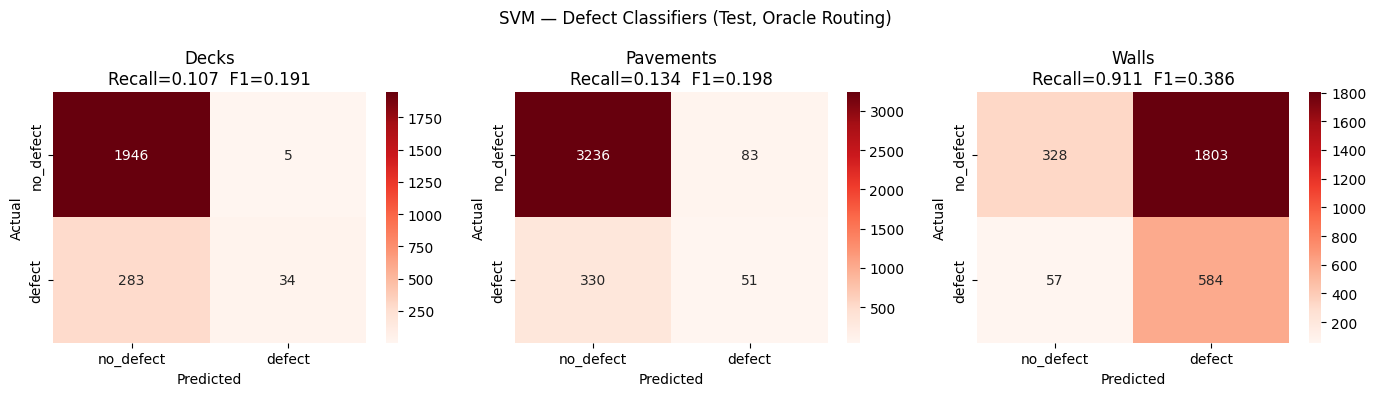

<Figure size 640x480 with 0 Axes>


--- KNN ---


  Decks: recall=0.502  prec=0.380  F1=0.433  AUC=0.713  (t=0.2)  FN=158


  Pavements: recall=0.223  prec=0.450  F1=0.298  AUC=0.657  (t=0.3)  FN=296


  Walls: recall=0.471  prec=0.323  F1=0.383  AUC=0.622  (t=0.2)  FN=339


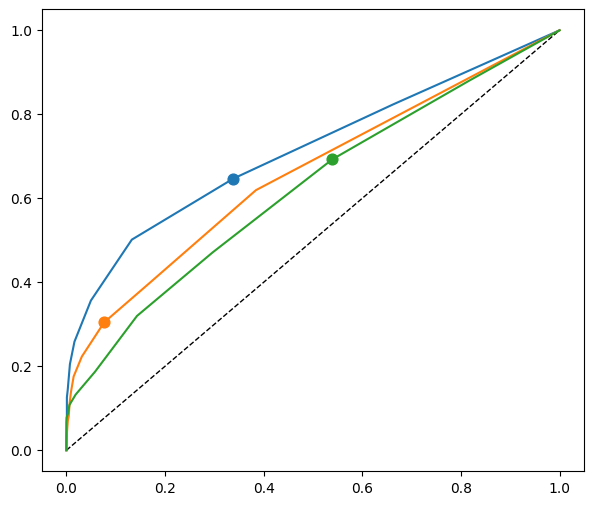

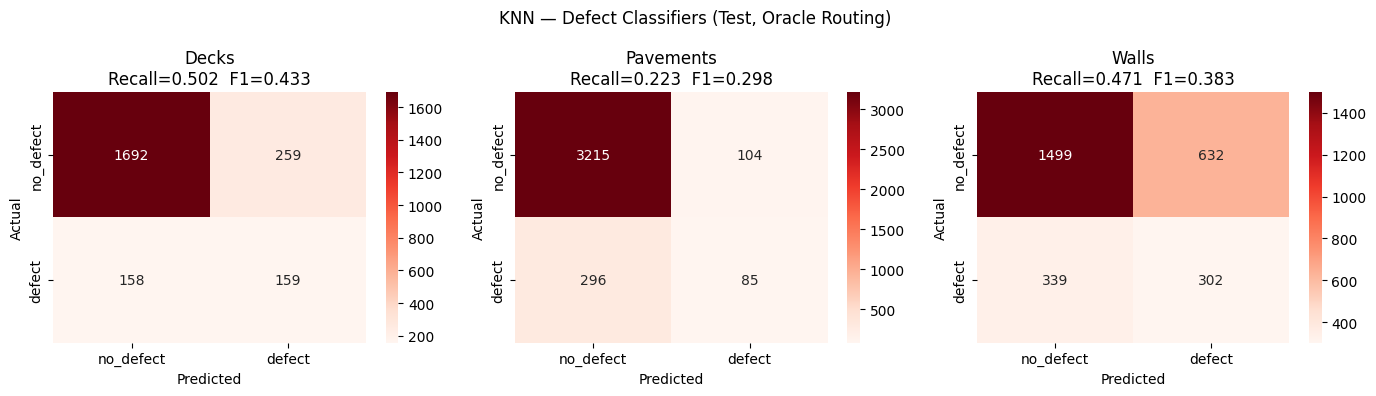

<Figure size 640x480 with 0 Axes>


--- Logistic Regression ---
  Decks: recall=0.593  prec=0.279  F1=0.379  AUC=0.706  (t=0.5)  FN=129


  Pavements: recall=0.593  prec=0.216  F1=0.316  AUC=0.690  (t=0.5)  FN=155
  Walls: recall=0.608  prec=0.324  F1=0.423  AUC=0.662  (t=0.5)  FN=251


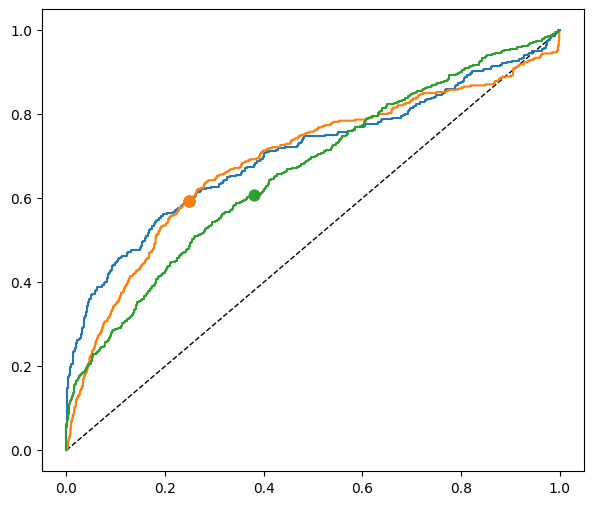

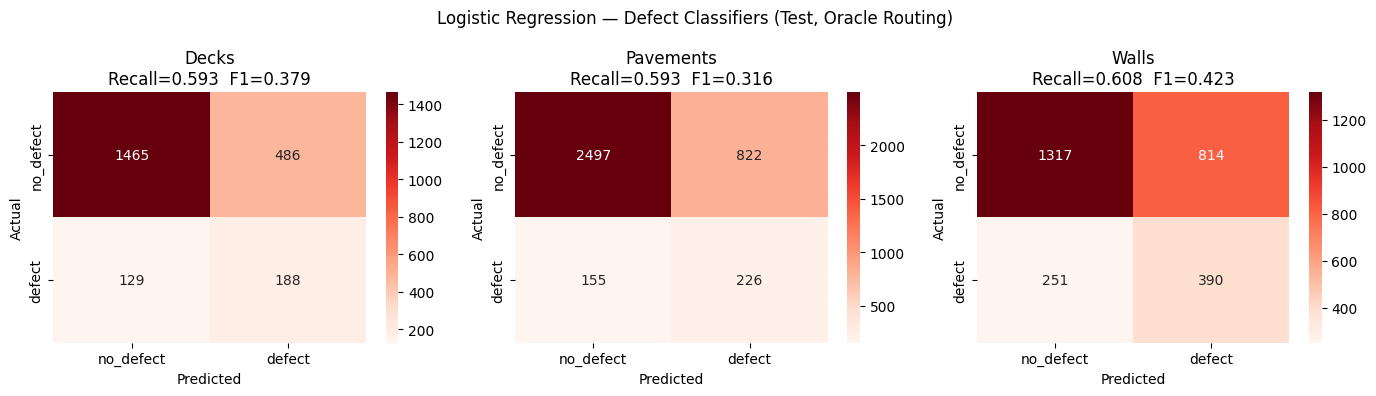

<Figure size 640x480 with 0 Axes>

In [4]:
all_results = {key: {} for key in MODEL_KEYS}

for key in MODEL_KEYS:
    print(f'\n--- {MODEL_LABELS[key]} ---')
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(14, 4))
    fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)

    for i, struct in enumerate(STRUCTURES):
        mask  = (df_test['structure'] == struct).values
        X_s   = X_test[mask]
        y_s   = df_test.loc[mask, 'defect_idx'].values
        t     = thresholds[key][struct]

        probs = defect_models[key][struct].predict_proba(X_s)[:, 1]
        preds = (probs >= t).astype(int)

        rec  = recall_score(y_s, preds, zero_division=0)
        prec = precision_score(y_s, preds, zero_division=0)
        f1   = f1_score(y_s, preds, zero_division=0)
        auc  = roc_auc_score(y_s, probs)
        cm   = confusion_matrix(y_s, preds)
        tn, fp, fn, tp = cm.ravel()

        all_results[key][struct] = dict(
            recall=rec, precision=prec, f1=f1, roc_auc=auc,
            confusion_matrix=cm, threshold=t,
            probs=probs, y_true=y_s, y_pred=preds,
        )
        print(f'  {struct}: recall={rec:.3f}  prec={prec:.3f}  F1={f1:.3f}  '
              f'AUC={auc:.3f}  (t={t})  FN={fn}')

        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes_cm[i],
                    xticklabels=['no_defect','defect'],
                    yticklabels=['no_defect','defect'])
        axes_cm[i].set_title(f'{struct}\nRecall={rec:.3f}  F1={f1:.3f}')
        axes_cm[i].set_xlabel('Predicted'); axes_cm[i].set_ylabel('Actual')

        fpr, tpr, thresh_vals = roc_curve(y_s, probs)
        op_idx = np.argmin(np.abs(thresh_vals - t))
        ax_roc.plot(fpr, tpr, label=f'{struct} (AUC={auc:.3f})')
        ax_roc.scatter(fpr[op_idx], tpr[op_idx], zorder=5, s=60)

    fig_cm.suptitle(f'{MODEL_LABELS[key]} — Defect Classifiers (Test, Oracle Routing)')
    fig_cm.tight_layout()
    plt.figure(fig_cm.number); plt.show()

    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR (Recall)')
    ax_roc.set_title(f'{MODEL_LABELS[key]} — ROC Curves (Oracle)')
    ax_roc.legend(loc='lower right')
    fig_roc.tight_layout()
    plt.figure(fig_roc.number); plt.show()

## End-to-End Pipeline Evaluation

Stage 1 predicts structure → routes to Stage 2 defect model → threshold applied.  
Oracle recall uses true structure labels for routing.

SVM: recall=0.506  prec=0.241  F1=0.327  AUC=0.668  oracle_recall=0.500  FN=661


KNN: recall=0.363  prec=0.339  F1=0.351  AUC=0.666  oracle_recall=0.408  FN=853
Logistic Regression: recall=0.561  prec=0.264  F1=0.359  AUC=0.682  oracle_recall=0.600  FN=588


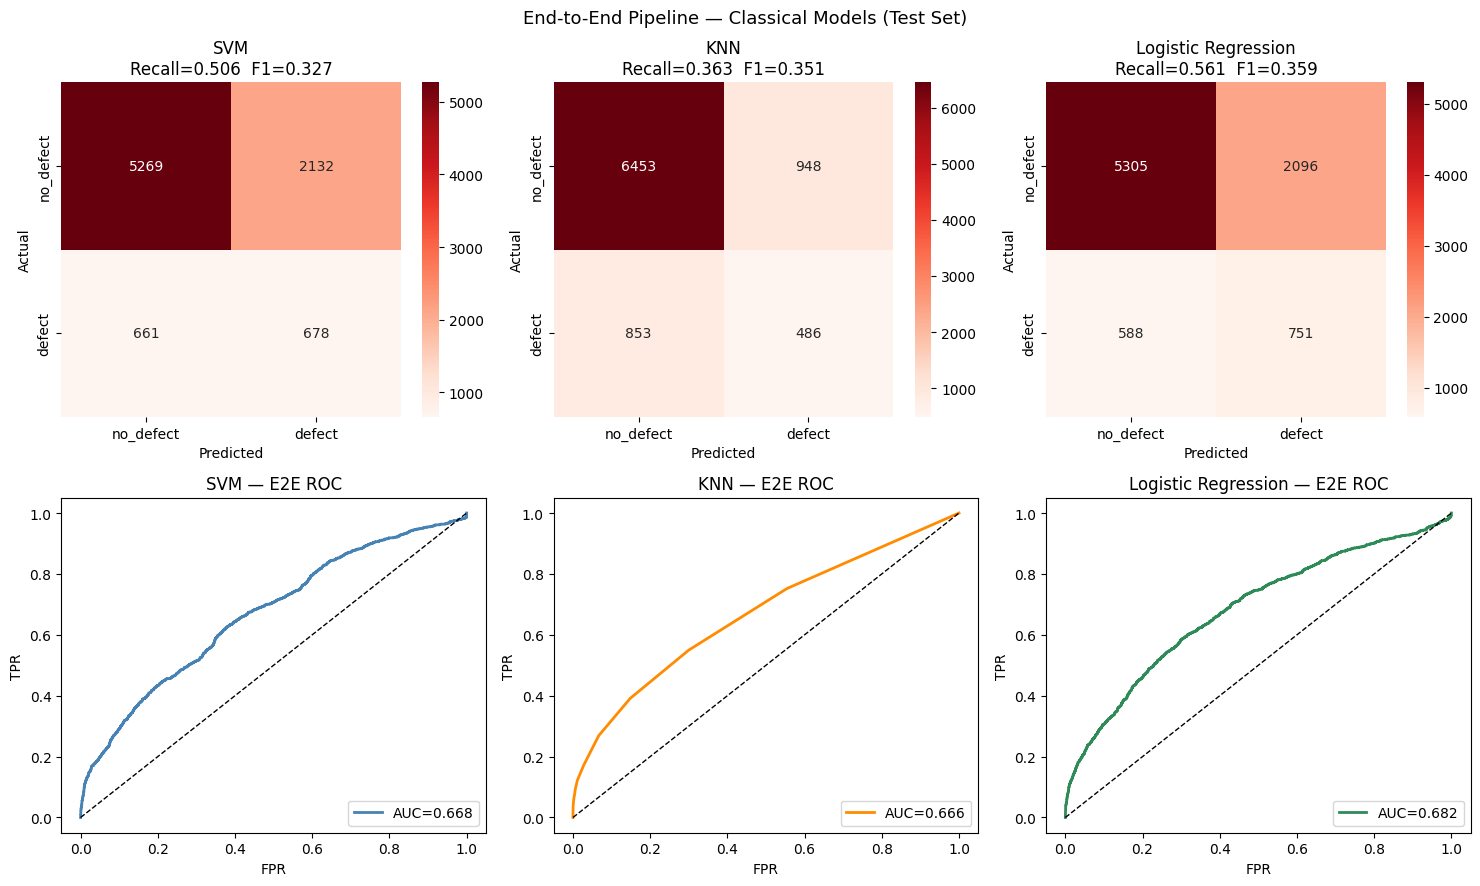

In [5]:
y_true_all = df_test['defect_idx'].values
e2e_metrics = {}

for key in MODEL_KEYS:
    struct_preds = structure_models[key].predict(X_test)
    e2e_probs = np.zeros(len(df_test))
    e2e_preds = np.zeros(len(df_test), dtype=int)

    for i, struct in enumerate(STRUCTURES):
        mask = struct_preds == i
        if mask.sum() == 0:
            continue
        t = thresholds[key][struct]
        probs_s = defect_models[key][struct].predict_proba(X_test[mask])[:, 1]
        e2e_probs[mask] = probs_s
        e2e_preds[mask] = (probs_s >= t).astype(int)

    # Oracle (true structure routing)
    oracle_probs = np.zeros(len(df_test))
    oracle_preds = np.zeros(len(df_test), dtype=int)
    for i, struct in enumerate(STRUCTURES):
        mask = df_test['structure_idx'].values == i
        if mask.sum() == 0:
            continue
        t = thresholds[key][struct]
        probs_s = defect_models[key][struct].predict_proba(X_test[mask])[:, 1]
        oracle_probs[mask] = probs_s
        oracle_preds[mask] = (probs_s >= t).astype(int)

    e2e_cm = confusion_matrix(y_true_all, e2e_preds)
    e2e_metrics[key] = dict(
        recall    = recall_score(y_true_all, e2e_preds, zero_division=0),
        precision = precision_score(y_true_all, e2e_preds, zero_division=0),
        f1        = f1_score(y_true_all, e2e_preds, zero_division=0),
        roc_auc   = roc_auc_score(y_true_all, e2e_probs),
        fn        = int(e2e_cm[1, 0]),
        oracle_recall = recall_score(y_true_all, oracle_preds, zero_division=0),
        e2e_probs = e2e_probs,
        e2e_cm    = e2e_cm,
    )
    m = e2e_metrics[key]
    print(f'{MODEL_LABELS[key]}: recall={m["recall"]:.3f}  prec={m["precision"]:.3f}  '
          f'F1={m["f1"]:.3f}  AUC={m["roc_auc"]:.3f}  '
          f'oracle_recall={m["oracle_recall"]:.3f}  FN={m["fn"]}')

# Plot E2E confusion matrices and ROC curves
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, key in enumerate(MODEL_KEYS):
    m = e2e_metrics[key]
    sns.heatmap(m['e2e_cm'], annot=True, fmt='d', cmap='Reds', ax=axes[0, col],
                xticklabels=['no_defect','defect'], yticklabels=['no_defect','defect'])
    axes[0, col].set_title(f'{MODEL_LABELS[key]}\nRecall={m["recall"]:.3f}  F1={m["f1"]:.3f}')
    axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true_all, m['e2e_probs'])
    axes[1, col].plot(fpr, tpr, color=COLORS[key], lw=2,
                      label=f'AUC={m["roc_auc"]:.3f}')
    axes[1, col].plot([0,1],[0,1],'k--', lw=1)
    axes[1, col].set_xlabel('FPR'); axes[1, col].set_ylabel('TPR')
    axes[1, col].set_title(f'{MODEL_LABELS[key]} — E2E ROC')
    axes[1, col].legend(loc='lower right')

fig.suptitle('End-to-End Pipeline — Classical Models (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

## Feature Importance — Logistic Regression Coefficients

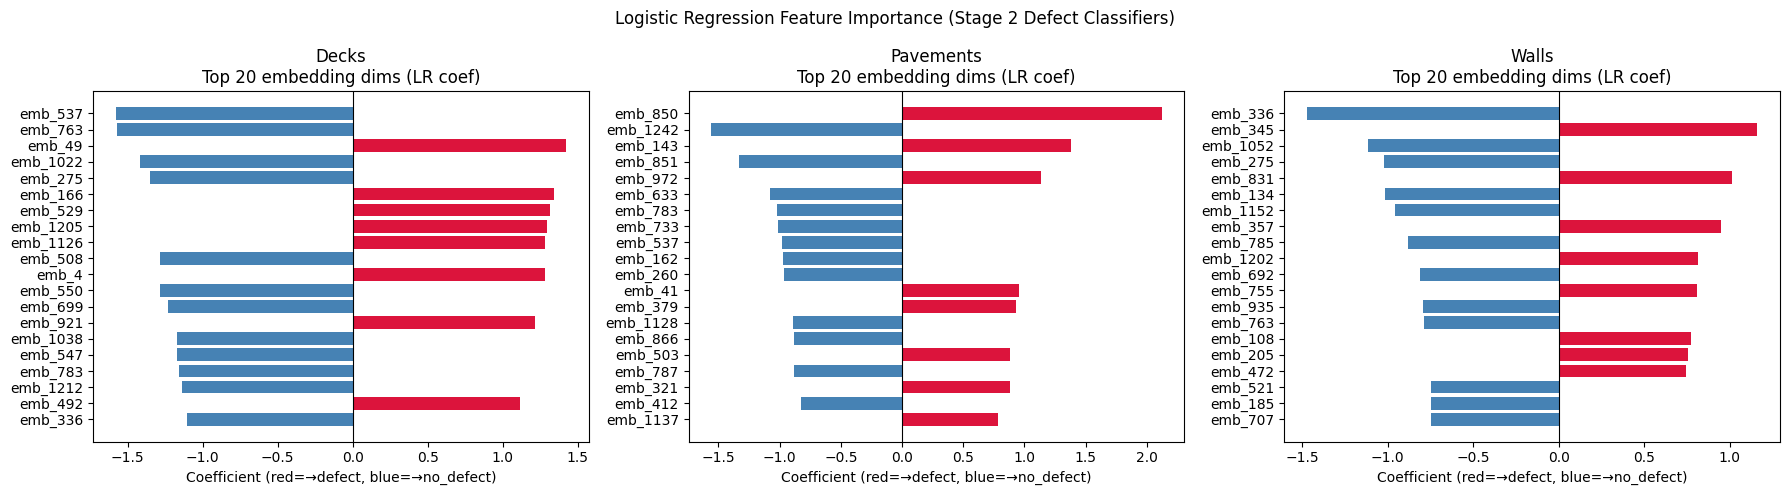

Note: SVM and LR share similar linear structure; KNN has no coefficients.


In [6]:
TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, struct in enumerate(STRUCTURES):
    lr_pipe = defect_models['lr'][struct]
    coef    = lr_pipe.named_steps['lr'].coef_[0]  # shape (1280,)
    top_idx = np.argsort(np.abs(coef))[-TOP_N:][::-1]
    top_vals = coef[top_idx]
    top_names = [f'emb_{j}' for j in top_idx]

    colors = ['crimson' if v > 0 else 'steelblue' for v in top_vals[::-1]]
    axes[i].barh(top_names[::-1], top_vals[::-1], color=colors)
    axes[i].axvline(0, color='black', lw=0.8)
    axes[i].set_title(f'{struct}\nTop {TOP_N} embedding dims (LR coef)')
    axes[i].set_xlabel('Coefficient (red=→defect, blue=→no_defect)')

fig.suptitle('Logistic Regression Feature Importance (Stage 2 Defect Classifiers)', fontsize=12)
plt.tight_layout()
plt.show()
print('Note: SVM and LR share similar linear structure; KNN has no coefficients.')

## 5-Model Comparison Summary

=== 5-Model E2E Comparison (Test Set) ===
              Model  S1 Acc  Recall  Precision    F1  ROC-AUC  FN (missed)
   CNN (fine-tuned)   0.859   0.834      0.370 0.513    0.882          222
            XGBoost   0.908   0.457      0.328 0.382    0.719          727
                SVM   0.907   0.506      0.241 0.327    0.668          661
                KNN   0.823   0.363      0.339 0.351    0.666          853
Logistic Regression   0.907   0.561      0.264 0.359    0.682          588


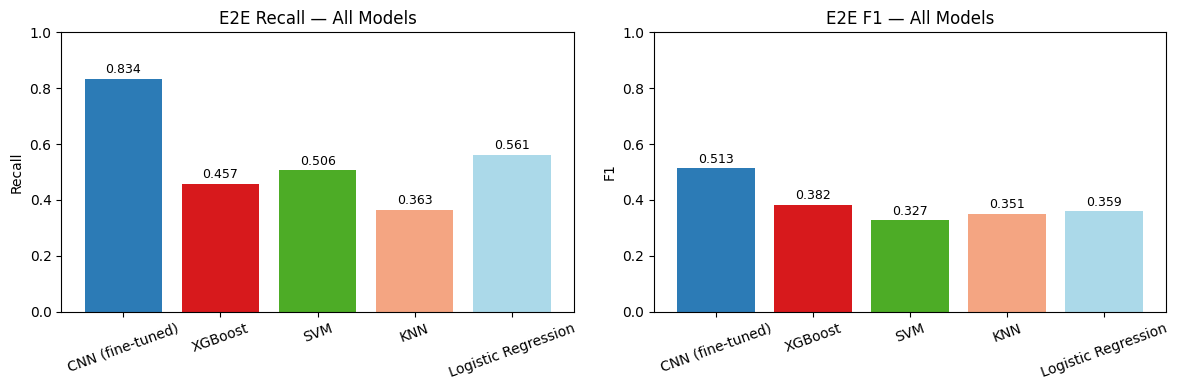


Saved reports/classical_pipeline_report.md


In [7]:
# CNN and XGBoost numbers from their respective pipeline reports (stable, pre-computed)
PRIOR_RESULTS = {
    'CNN (fine-tuned)': dict(s1_acc=0.859, recall=0.834, precision=0.370, f1=0.513, roc_auc=0.882, fn=222),
    'XGBoost':          dict(s1_acc=0.908, recall=0.457, precision=0.328, f1=0.382, roc_auc=0.719, fn=727),
}

rows = []
for label, vals in PRIOR_RESULTS.items():
    rows.append({'Model': label, **{k: v for k, v in vals.items()}})

for key in MODEL_KEYS:
    m = e2e_metrics[key]
    rows.append({
        'Model':     MODEL_LABELS[key],
        's1_acc':    round(s1_accs[key], 3),
        'recall':    round(m['recall'],    3),
        'precision': round(m['precision'], 3),
        'f1':        round(m['f1'],        3),
        'roc_auc':   round(m['roc_auc'],   3),
        'fn':        m['fn'],
    })

df_compare = pd.DataFrame(rows).rename(columns={
    's1_acc': 'S1 Acc', 'recall': 'Recall', 'precision': 'Precision',
    'f1': 'F1', 'roc_auc': 'ROC-AUC', 'fn': 'FN (missed)'
})

print('=== 5-Model E2E Comparison (Test Set) ===')
print(df_compare.to_string(index=False))

# Bar chart comparing Recall and F1 across models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = ['#2c7bb6', '#d7191c', '#4dac26', '#f4a582', '#abd9e9']
for ax, metric in zip(axes, ['Recall', 'F1']):
    bars = ax.bar(df_compare['Model'], df_compare[metric], color=palette)
    ax.set_ylabel(metric)
    ax.set_title(f'E2E {metric} — All Models')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, df_compare[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Write report
Path('reports').mkdir(exist_ok=True)
with open('reports/classical_pipeline_report.md', 'w') as f:
    f.write('# Classical ML Pipeline Report\n\n')
    f.write(f'*Generated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}*\n\n')
    f.write('## 5-Model Comparison (End-to-End, Test Set)\n\n')
    f.write(df_compare.to_markdown(index=False) + '\n\n')
    f.write('---\n*Generated by `classical_eval.ipynb`*\n')
print('\nSaved reports/classical_pipeline_report.md')

## Self-Check

In [8]:
print('=== Self-Check ===')
errors = []

# 1. Artifact existence
expected_files = (
    [f'models/classical/{k}_structure_model.pkl' for k in MODEL_KEYS] +
    [f'models/classical/{k}_defect_{s.lower()}.pkl' for k in MODEL_KEYS for s in STRUCTURES] +
    ['models/classical/classical_thresholds.json',
     'reports/classical_pipeline_report.md']
)
for fname in expected_files:
    if Path(fname).exists():
        print(f'  [OK] {fname}')
    else:
        print(f'  [MISSING] {fname}')
        errors.append(f'Missing file: {fname}')

# 2. Sanity check: all Stage 1 accuracies above random (>33%)
for key in MODEL_KEYS:
    acc = s1_accs[key]
    if acc > 0.33:
        print(f'  [OK] {MODEL_LABELS[key]} Stage 1 accuracy={acc:.3f} (>0.33 random)')
    else:
        msg = f'{MODEL_LABELS[key]} Stage 1 accuracy={acc:.3f} is at or below random!'
        print(f'  [FAIL] {msg}'); errors.append(msg)

# 3. Sanity check: all E2E ROC-AUCs above 0.5
for key in MODEL_KEYS:
    auc = e2e_metrics[key]['roc_auc']
    if auc > 0.5:
        print(f'  [OK] {MODEL_LABELS[key]} E2E AUC={auc:.3f} (>0.5)')
    else:
        msg = f'{MODEL_LABELS[key]} E2E AUC={auc:.3f} is at or below random!'
        print(f'  [FAIL] {msg}'); errors.append(msg)

# 4. Sanity check: predict on a single test sample without error
sample = X_test[:1]
for key in MODEL_KEYS:
    for struct in STRUCTURES:
        try:
            prob = defect_models[key][struct].predict_proba(sample)[0, 1]
            assert 0.0 <= prob <= 1.0, f'prob={prob} out of range'
        except Exception as e:
            msg = f'{key}/{struct} predict_proba failed: {e}'
            print(f'  [FAIL] {msg}'); errors.append(msg)
print('  [OK] All models predict_proba on single sample without error')

print()
if errors:
    print(f'SELF-CHECK FAILED — {len(errors)} issue(s):')
    for e in errors:
        print(f'  - {e}')
else:
    print('SELF-CHECK PASSED — all checks green.')

=== Self-Check ===
  [OK] models/classical/svm_structure_model.pkl
  [OK] models/classical/knn_structure_model.pkl
  [OK] models/classical/lr_structure_model.pkl
  [OK] models/classical/svm_defect_decks.pkl
  [OK] models/classical/svm_defect_pavements.pkl
  [OK] models/classical/svm_defect_walls.pkl
  [OK] models/classical/knn_defect_decks.pkl
  [OK] models/classical/knn_defect_pavements.pkl
  [OK] models/classical/knn_defect_walls.pkl
  [OK] models/classical/lr_defect_decks.pkl
  [OK] models/classical/lr_defect_pavements.pkl
  [OK] models/classical/lr_defect_walls.pkl
  [OK] models/classical/classical_thresholds.json
  [OK] reports/classical_pipeline_report.md
  [OK] SVM Stage 1 accuracy=0.907 (>0.33 random)
  [OK] KNN Stage 1 accuracy=0.823 (>0.33 random)
  [OK] Logistic Regression Stage 1 accuracy=0.907 (>0.33 random)
  [OK] SVM E2E AUC=0.668 (>0.5)
  [OK] KNN E2E AUC=0.666 (>0.5)
  [OK] Logistic Regression E2E AUC=0.682 (>0.5)


  [OK] All models predict_proba on single sample without error

SELF-CHECK PASSED — all checks green.
